In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [74]:
import psycopg2
connection = psycopg2.connect(
    host="localhost",
    port=5433,
    database="churn_db",   # DB name
    user="customer",       # DB user
    password="customerchurn123" # DB password
)

In [75]:
data = pd.read_csv('../Datasets/churnData.csv')
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Cleaning the Dataset 



In [76]:
## Checking the null data 
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [77]:
## Checking the null values 

print(data.isna().any())

### There are no any such null values in the whole dataset!

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool


In [78]:
(data == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [79]:
novalues = data[data.TotalCharges == " "].columns

In [80]:
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data.fillna(data['TotalCharges'].mean())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [81]:
### Lets see if other columns have the missing values
data[data['tenure'] == 0]

### here tenure = 0 means that the total months is 0 which is irrelavant for this dataset, so we will drop all those values

data.drop(labels=data[data['tenure'] == 0].index , axis = 0, inplace=True)

## We have dropped all those rows which had the missing values or irrelavant values in them.

In [82]:
### Converting to the actual dataframe for sql analysis 

data.to_csv('../Datasets/cleaned.csv')

---
### EDA with SQL, Matplotlib, Pandas, and Seaborn 

--- 
### Gender Distribution in the dataset 



In [83]:
query = """-- Gender Distribution 
with genderdistribution as (
select "gender", count(*) as total 
from cleaned
group by "gender"
),
genderchurn as (
select "gender", ROUND(100 * SUM(case when "Churn" = 'Yes' then 1 else 0 end )::numeric / COUNT(*), 2) as genderchurn
from cleaned
group by "gender")

select g1."gender", g1.total, g2.genderchurn
from genderdistribution as g1
join genderchurn as g2
on g1."gender" = g2."gender" """

gender_distributions = pd.read_sql(query, connection)
gender_distributions.head(2)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/3941384281.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gender_distributions = pd.read_sql(query, connection)


,gender,total,genderchurn
0,Female,3488,26.92
1,Male,3555,26.16


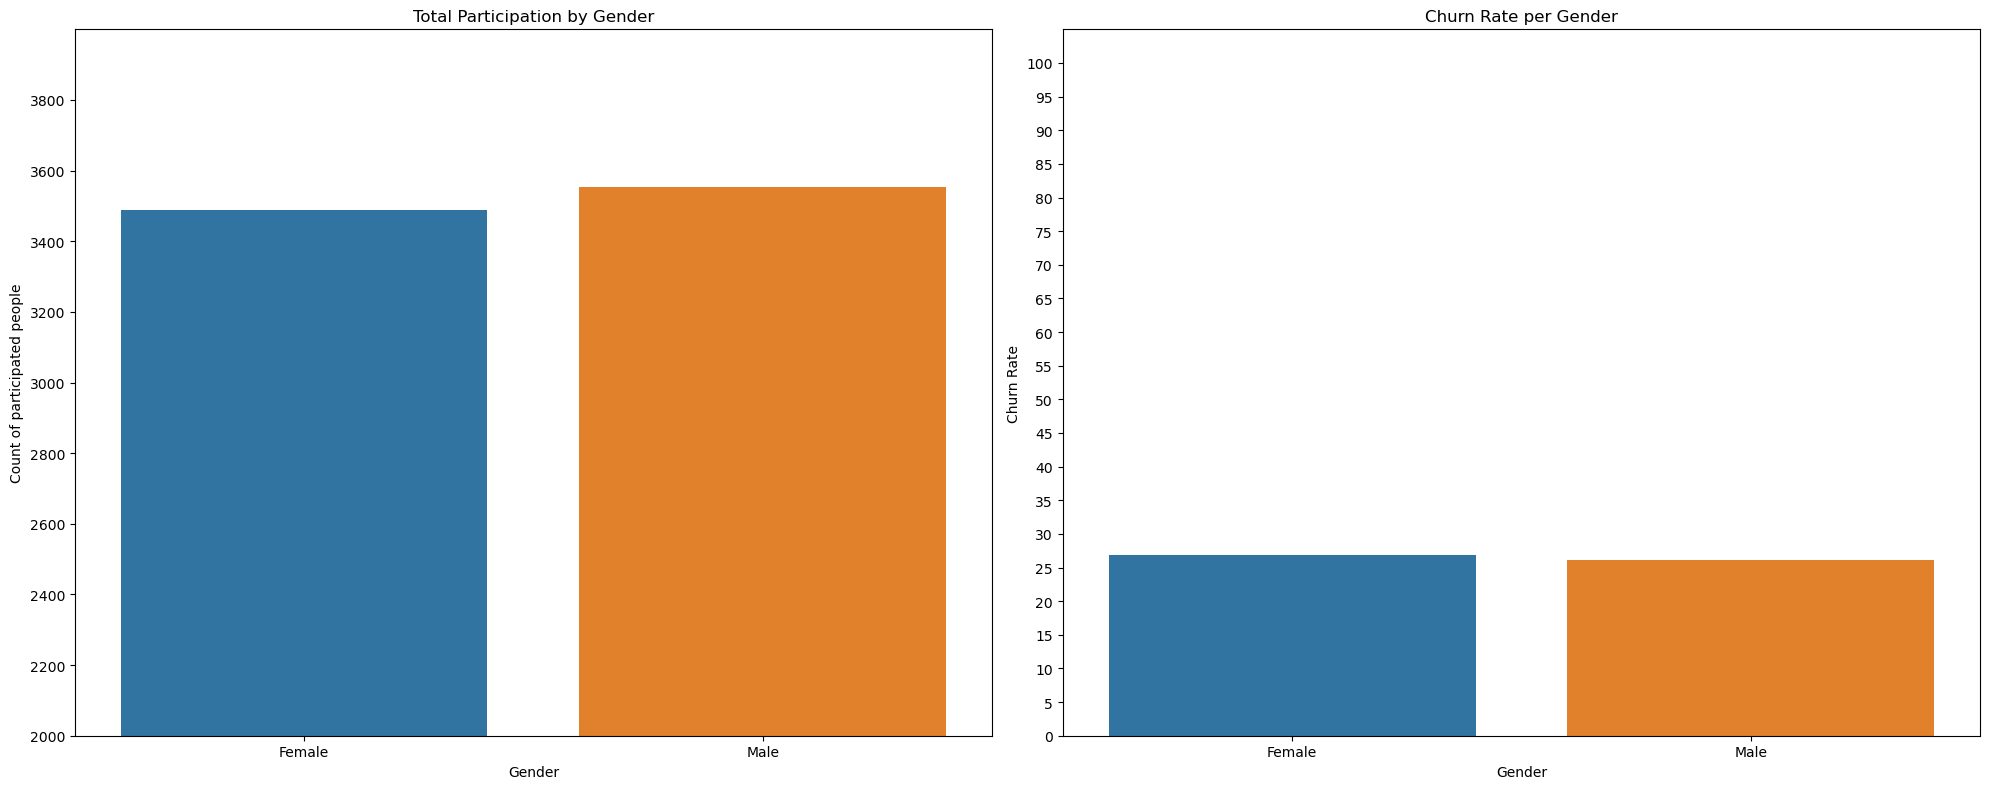

In [84]:
fig, ax = plt.subplots(1,2,figsize = (20,8))
def gender_distribution(x, y , data, title, xlabel, ylabel, ylim1,ylim2, axes,num):
    sns.barplot(x = x, y = y , data = data, hue = x,  ax = axes)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.set_yticks(np.arange(ylim1,ylim2, num))
    axes.set_ylim(ylim1, ylim2)
    plt.tight_layout()

gender_distribution("gender", "total", gender_distributions, "Total Participation by Gender", "Gender", "Count of participated people", 2000,4000,ax[0], 200 )
gender_distribution("gender", "genderchurn", gender_distributions, "Churn Rate per Gender", "Gender", "Churn Rate", 0,105,ax[1], 5 )

---
### Senior Citizen Participation in the datsets


In [85]:
query = """ 
with seniordistribution as (
select "SeniorCitizen", count(*) as total 
from cleaned
group by "SeniorCitizen")
,
seniorchurn as (
select "SeniorCitizen", ROUND(100 * SUM(case when "Churn" = 'Yes' then 1 else 0 end )::numeric / COUNT(*), 2) as total 
from cleaned
group by "SeniorCitizen"
)

select s1."SeniorCitizen", s1.total as seniorcount, s2.total as seniorchurn
from seniordistribution as s1
join seniorchurn as s2
on s1."SeniorCitizen" = s2."SeniorCitizen"
"""

seniorparticipation = pd.read_sql(query,connection)
seniorparticipation['SeniorCitizen'] = seniorparticipation['SeniorCitizen'].map({0:'No',1:'Yes'})
seniorparticipation.head(2)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/1448907346.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  seniorparticipation = pd.read_sql(query,connection)


,SeniorCitizen,seniorcount,seniorchurn
0,No,5901,23.61
1,Yes,1142,41.68


In [86]:
sns.barplot(x = 'SeniorCitizen', y = 'total', data = seniorparticipation, hue = 'SeniorCitizen')
plt.xlabel("Is Senior Citizen?")
plt.ylabel("Count of participated people")
plt.ylim(0,6000)
plt.title("Senior Citizen Participation")
plt.show()

ValueError: Could not interpret value `total` for `y`. An entry with this name does not appear in `data`.

---

### Count of the total churn customers vs non-churn 


In [ ]:
query = """
select "Churn", count(*) as total
from cleaned
group by "Churn"
"""

churndetails = pd.read_sql(query, connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/207033286.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  churndetails = pd.read_sql(query, connection)


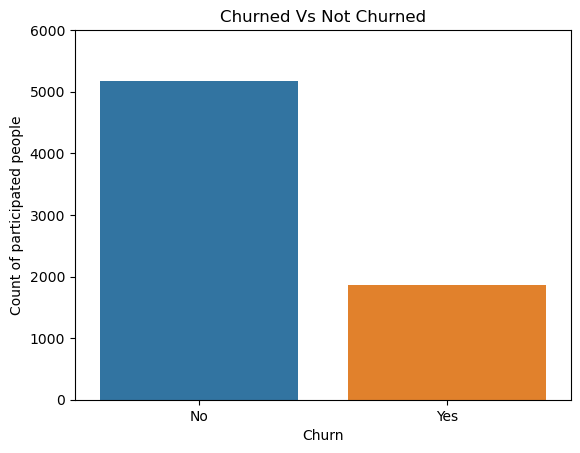

In [ ]:
sns.barplot(x = 'Churn', y = 'total', data = churndetails, hue = 'Churn')
plt.ylabel("Count of participated people")
plt.ylim(0,6000)
plt.title("Churned Vs Not Churned")
plt.show()

---
### Average Tenure for churned vs non churned customers


In [ ]:
query = """
    select "Churn", ROUND(avg("tenure")::numeric, 0) as average
    from cleaned
    group by "Churn"
"""
averagemonths = pd.read_sql(query,connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/193009145.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  averagemonths = pd.read_sql(query,connection)


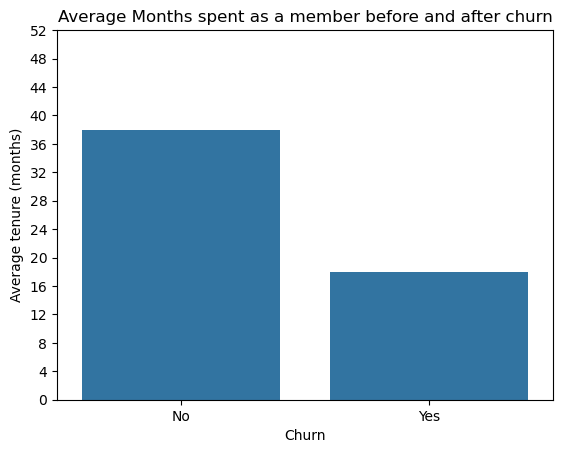

In [ ]:
sns.barplot(x = 'Churn', y = 'average', data = averagemonths)
plt.ylabel("Average tenure (months)")
plt.ylim(0,50)
plt.title("Average Months spent as a member before and after churn")
plt.yticks(np.arange(0,54,4))
plt.show()

---
### Relation between the Average Monthly Charge and Churn Customers 


In [ ]:
query = """
select "Churn", ROUND(AVG("MonthlyCharges")::numeric ,2) as amountPaid
from cleaned
group by "Churn" 
"""

monthlyaveragechurned = pd.read_sql(query, connection)
monthlyaveragechurned.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/4052769378.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthlyaveragechurned = pd.read_sql(query, connection)


,Churn,amountpaid
0,No,61.27
1,Yes,74.44


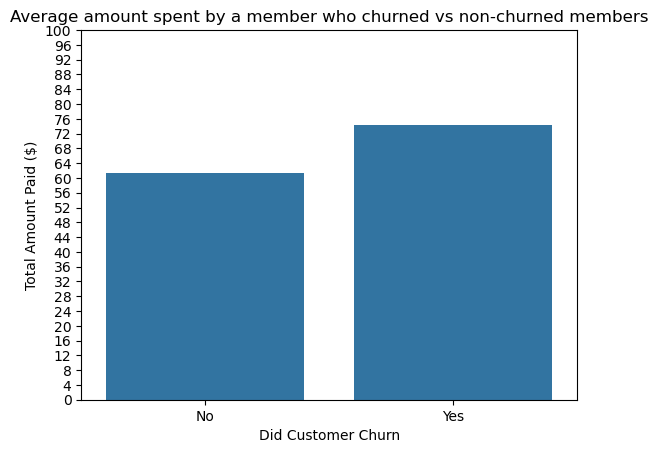

In [ ]:
### Total Amount Paid by the churn vs non-churn customers
sns.barplot(x = 'Churn', y = 'amountpaid', data = monthlyaveragechurned)
plt.xlabel("Did Customer Churn")
plt.ylabel("Total Amount Paid ($)")
plt.ylim(0,100)
plt.title("Average amount spent by a member who churned vs non-churned members")
plt.yticks(np.arange(0,102,4))
plt.show()

### As we can see the amount paid by customer who churned was 13$ more on average compared to the one who did not churn. This suggests us that the price might also be a factor on why the customer churned

---

### Types of Contract of the Churned Customers

In [ ]:
query = """ 
select "Contract", ROUND(100 * SUM(case when "Churn" = 'Yes' then 1 else 0 end)::numeric/count(*),2) as eachcategory 
from cleaned
group by "Contract"

"""
contract_churn = pd.read_sql(query, connection)
contract_churn.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/1758664510.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  contract_churn = pd.read_sql(query, connection)


,Contract,eachcategory
0,One year,11.27
1,Month-to-month,42.71
2,Two year,2.83


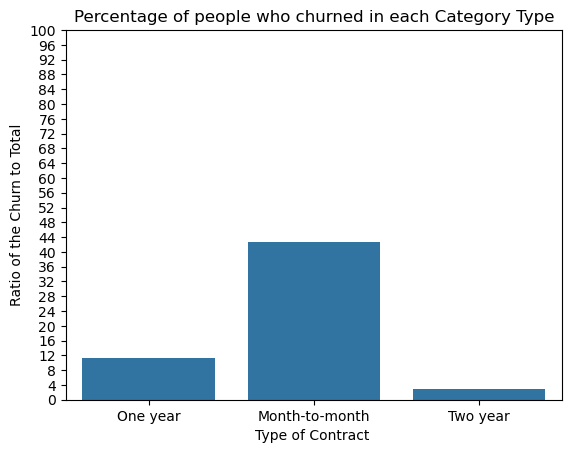

In [ ]:
sns.barplot(x = 'Contract', y = 'eachcategory', data = contract_churn)
plt.xlabel("Type of Contract ")
plt.ylabel("Ratio of the Churn to Total")
plt.ylim(0,100)
plt.title("Percentage of people who churned in each Category Type")
plt.yticks(np.arange(0,104,4))
plt.show()

### As seen there are more month-to-month category users who churned compared to other category types suggesting the category types may also effect user's decisions.

---
### Types of Payment Method used by Churned Customers 

In [ ]:
query = """ 
select "PaymentMethod", ROUND(100 * SUM(case when "Churn" = 'Yes' then 1 else 0 end)::numeric/count(*),2) as paymentratio
from cleaned
group by "PaymentMethod" 
"""

paymentused = pd.read_sql(query,connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/1581882869.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  paymentused = pd.read_sql(query,connection)


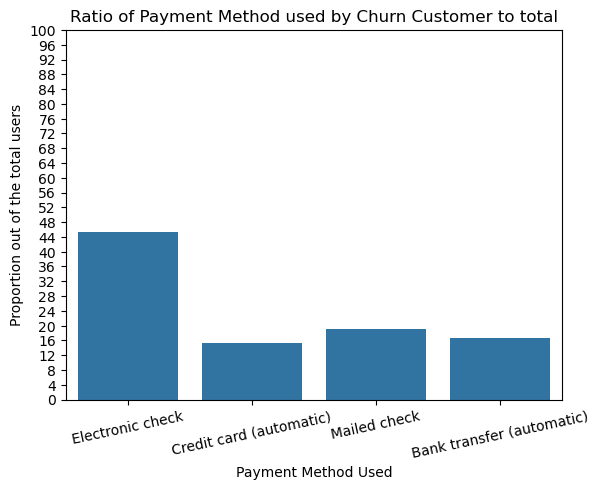

In [ ]:
sns.barplot(x = 'PaymentMethod', y = 'paymentratio', data = paymentused)
plt.xlabel("Payment Method Used")
plt.ylabel("Proportion out of the total users")
plt.ylim(0,100)
plt.title("Ratio of Payment Method used by Churn Customer to total")
plt.yticks(np.arange(0,104,4))
plt.xticks(rotation = 12)
plt.show()

### As seen from the chart, Electronic Check were the most used payment method used by the customers who churned

---

### Lets see what percent of total revenue loss is done by each payment category in Month-Month Contract. Month-Month contract has been choosen because nearly half of the churned customers fall in the Month-Month Contract
 

In [ ]:
query = """ 
with monthtomonth as (
	select "Contract", "PaymentMethod", SUM("TotalCharges") as totalrevenue
	from cleaned
	where "Contract" = 'Month-to-month' and "Churn" = 'Yes' 
	group by "Contract", "PaymentMethod"
), 
totalloss as (
select "Contract", SUM("TotalCharges") as totalloss
from cleaned
where "Contract" = 'Month-to-month' and "Churn" = 'Yes'
group by "Contract"
)

select m."Contract", m."PaymentMethod", 100 * (m.totalrevenue/t.totalloss )as percent
from monthtomonth as m 
join totalloss as t
on m."Contract" = t."Contract"
"""

monthspecific = pd.read_sql(query, connection)

print(monthspecific)

         Contract              PaymentMethod    percent
0  Month-to-month           Electronic check  62.678951
1  Month-to-month    Credit card (automatic)  15.172946
2  Month-to-month               Mailed check   5.717602
3  Month-to-month  Bank transfer (automatic)  16.430457


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/3813486424.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthspecific = pd.read_sql(query, connection)


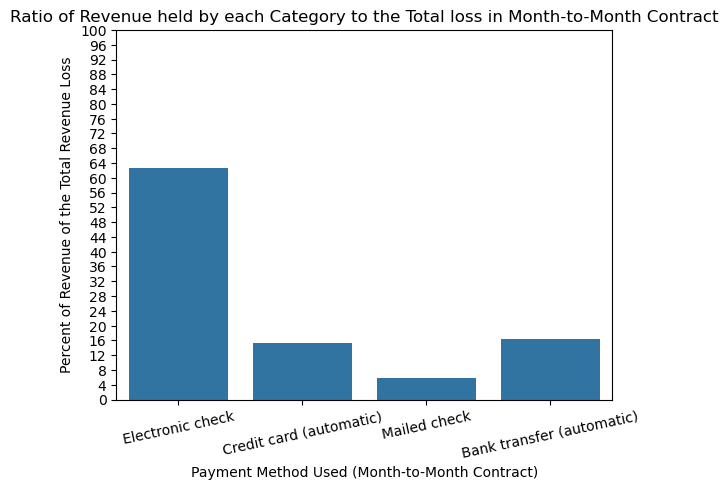

In [ ]:
sns.barplot(x = 'PaymentMethod', y = 'percent', data = monthspecific)
plt.xlabel("Payment Method Used (Month-to-Month Contract)")
plt.ylabel("Percent of Revenue of the Total Revenue Loss")
plt.ylim(0,100)
plt.title("Ratio of Revenue held by each Category to the Total loss in Month-to-Month Contract")
plt.yticks(np.arange(0,104,4))
plt.xticks(rotation = 12)
plt.show()

### As seen from the graph electronic check method holds the highest revenue out of the total loss generated from the Month-Month Contract

---
### Evaluating the tenure of the churned customers

In [ ]:
## Here we have seperated the months in terms of years

query = """ 
with tenureyears as (select *,
case 
	when "tenure" >=0 and "tenure" <= 12 then '12 months'
	when "tenure" > 12 and "tenure" <= 24 then '24 months'
	when "tenure" > 24 and "tenure" <= 48 then '48 months'
	else '4 years +'
end as tenureyears

from cleaned)


select "tenureyears", count(*) as total
from tenureyears
where "Churn" = 'Yes'
group by tenureyears
order by "tenureyears"
"""

monthlytenure = pd.read_sql(query, connection)


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/63829831.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthlytenure = pd.read_sql(query, connection)


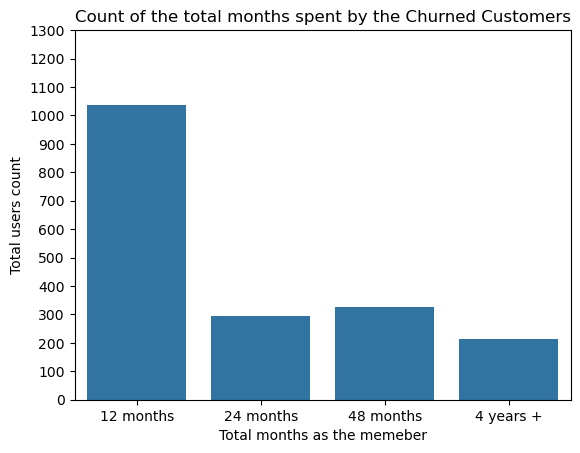

In [ ]:
sns.barplot(x = 'tenureyears', y = 'total', data = monthlytenure)
plt.yticks(np.arange(0,1400,100))
plt.xlabel("Total months as the memeber")
plt.ylabel("Total users count")
plt.title("Count of the total months spent by the Churned Customers")
plt.show()

### We can see most of the customers who churned had the average tenure of 12 months, whereas 4 years+ have the lowest total in the whole chart

---
### Churn rate per tenure bucket 

In [ ]:
query = """ 
with tenureyears as (select *,
case 
	when "tenure" >=0 and "tenure" <= 12 then '12 months'
	when "tenure" > 12 and "tenure" <= 24 then '24 months'
	when "tenure" > 24 and "tenure" <= 48 then '48 months'
	else '4 years +'
end as tenureyears

from cleaned)

select  "tenureyears", ROUND(100* (sum(case when "Churn" = 'Yes' then 1 else 0 end)::numeric / COUNT(*)),2) as ratio
from tenureyears
group by "tenureyears"
order by "tenureyears"
"""

churnrate = pd.read_sql(query,connection)
churnrate.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/3002295333.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  churnrate = pd.read_sql(query,connection)


,tenureyears,ratio
0,12 months,47.44
1,24 months,28.71
2,48 months,20.39
3,4 years +,9.51


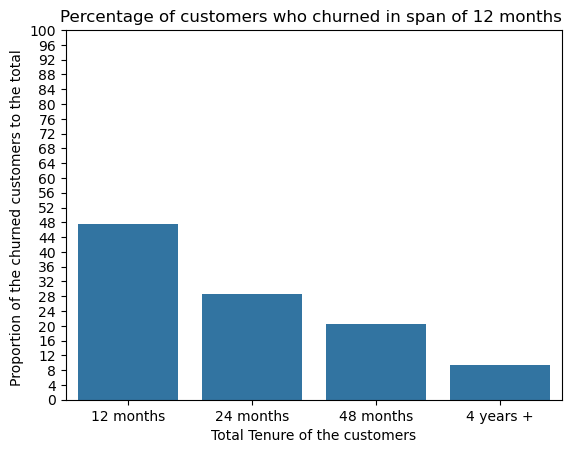

In [ ]:
sns.barplot(x = 'tenureyears', y = 'ratio', data = churnrate)
plt.xlabel("Total Tenure of the customers")
plt.ylabel("Proportion of the churned customers to the total ")
plt.ylim(0,100)
plt.title("Percentage of customers who churned in span of 12 months ")
plt.yticks(np.arange(0,104,4))
plt.show()

### As seen from the graph, customers with tenure of 0–12 months have the highest churn rate compared to longer-tenured customers. This suggests that churn risk is significantly higher during the first year of the customer lifecycle, and customers are most likely to leave early rather than after long-term engagement.

---
### Service Usage Analysis !



In [ ]:
query = """ 

select "InternetService",
ROUND(100 * SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END)::numeric / COUNT(*), 2) AS churn_rate
from cleaned
group by "InternetService" 
order by churn_rate desc

"""

eachservicechurn = pd.read_sql(query,connection)
print(eachservicechurn)

  InternetService  churn_rate
0     Fiber optic       41.89
1             DSL       18.96
2              No        7.40


/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/3591988935.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  eachservicechurn = pd.read_sql(query,connection)


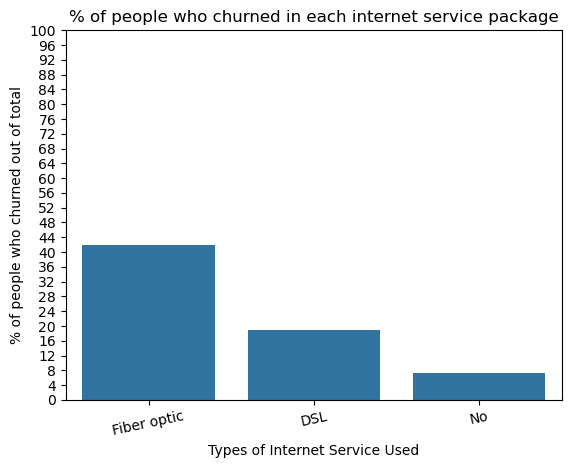

In [ ]:
sns.barplot(x = 'InternetService', y = 'churn_rate', data = eachservicechurn)
plt.xlabel("Types of Internet Service Used")
plt.ylabel("% of people who churned out of total")
plt.ylim(0,100)
plt.title("% of people who churned in each internet service package")
plt.yticks(np.arange(0,104,4))
plt.xticks(rotation = 12)
plt.show()

### FiberOptic has the highest churn rate compared to other internet service methods
---

### Churn rate of the customers based on the number of services they used. Services include: Streaming TV, Streaming Movies, Online Backup, and DeviceProtection, OnlineSecurity, Tech Support 

In [ ]:
query = """ 
with each_service as (
	
	select *,
	(case when "StreamingTV" = 'Yes' then 1 else 0 end + 
	 case when "StreamingMovies" = 'Yes' then 1 else 0 end + 
	 case when "OnlineBackup" = 'Yes' then 1 else 0 end + 
	 case when "DeviceProtection" = 'Yes' then 1 else 0 end +
	 case when "OnlineSecurity" = 'Yes' then 1 else 0 end+
	 case when "TechSupport" = 'Yes' then 1 else 0 end) as total_services_used
	from cleaned
	where "InternetService" <> 'No'
	
)

select total_services_used,
ROUND(100 * SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END)::numeric / COUNT(*), 2)
from each_service
group by total_services_used

"""

serviceschurnrate = pd.read_sql(query,connection)
serviceschurnrate.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/1408032721.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  serviceschurnrate = pd.read_sql(query,connection)


,total_services_used,round
0,4,22.30
1,6,5.28
2,2,35.82
3,3,27.37
4,0,52.24


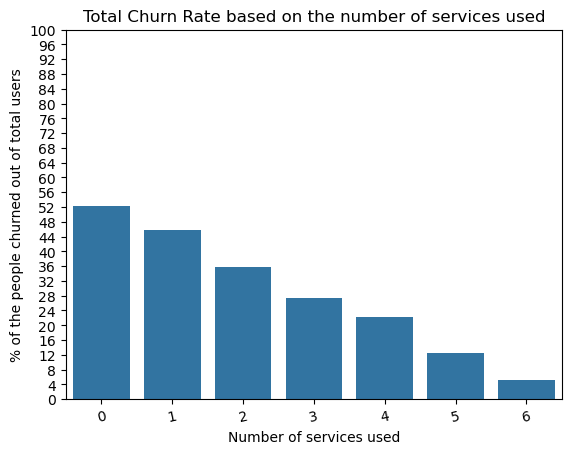

In [ ]:
### Graphical representation 

sns.barplot(x = 'total_services_used', y = 'round', data = serviceschurnrate)
plt.ylabel("% of the people churned out of total users")
plt.xlabel("Number of services used")
plt.ylim(0,100)
plt.title("Total Churn Rate based on the number of services used")
plt.yticks(np.arange(0,104,4))
plt.xticks(rotation = 12)
plt.show()

### Average total charges for churned vs non churned customers 



In [ ]:
query = """
select ROUND(AVG("TotalCharges")::numeric,2) as avg_cost_paid, "Churn"
from cleaned
group by "Churn"
"""

averageCost = pd.read_sql(query,connection)

averageCost.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/2119405833.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  averageCost = pd.read_sql(query,connection)


,avg_cost_paid,Churn
0,2555.34,No
1,1531.80,Yes


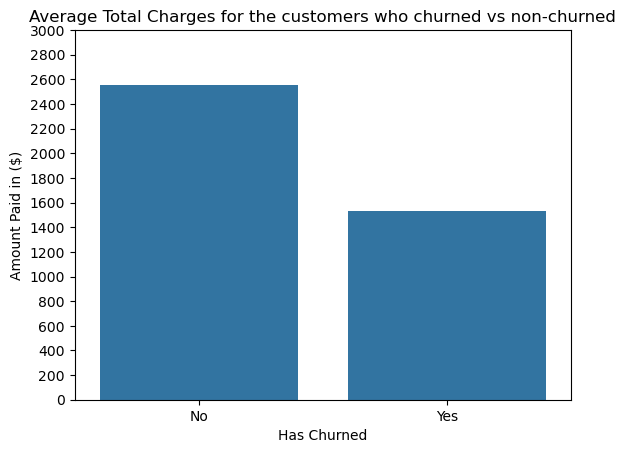

In [ ]:
sns.barplot(x = 'Churn', y = 'avg_cost_paid', data = averageCost)
plt.ylabel("Amount Paid in ($)")
plt.xlabel("Has Churned")
plt.ylim(0,3000)
plt.title("Average Total Charges for the customers who churned vs non-churned")
plt.yticks(np.arange(0,3200,200))
plt.show()

---
### Distribution of Monthly Charges for Churned vs Non Churned Customers


In [ ]:
query = """ 

select "MonthlyCharges", "Churn"
from cleaned 

"""

monthlystats = pd.read_sql(query,connection)

print(monthlystats)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/1842107752.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthlystats = pd.read_sql(query,connection)


      MonthlyCharges Churn
0              29.85    No
1              56.95    No
2              53.85   Yes
3              42.30    No
4              70.70   Yes
...              ...   ...
7038           84.80    No
7039          103.20    No
7040           29.60    No
7041           74.40   Yes
7042          105.65    No

[7043 rows x 2 columns]


In [ ]:
query = """ 

select "MonthlyCharges", "Churn"
from cleaned 

"""
monthlystats = pd.read_sql(query,connection)
monthlystats.head()

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/2473097056.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthlystats = pd.read_sql(query,connection)


,MonthlyCharges,Churn
0,29.85,No
1,56.95,No
2,53.85,Yes
3,42.30,No
4,70.70,Yes


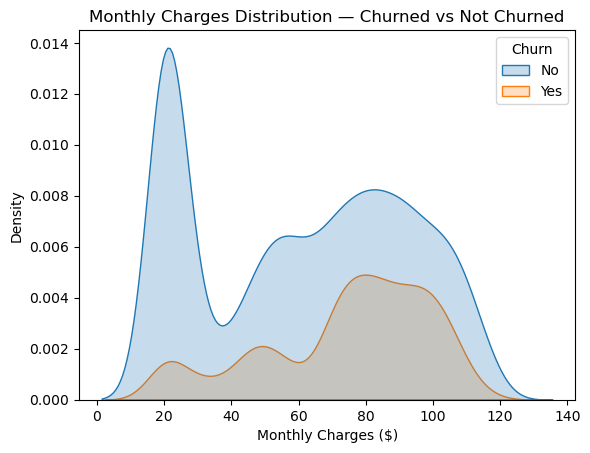

In [ ]:
sns.kdeplot(data = monthlystats,x = 'MonthlyCharges', hue = 'Churn', fill=True)
plt.title("Monthly Charges Distribution — Churned vs Not Churned")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")
plt.show()

---

### Profile of the customers 

### Customers with the Tenure of more than 48 months 
---
### Total Money Paid Stats

In [ ]:
query = """ 
with amountstats as (
select "Churn", ROUND(AVG("MonthlyCharges")::numeric,2) as averagemonthly, ROUND(AVG("TotalCharges")::numeric,2) as totalcharges,COUNT(*) as totalchurn 
from cleaned
where "tenure" >= 48
group by "Churn")

select * from amountstats
"""

moneyfouryears = pd.read_sql(query, connection)
moneyfouryears.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/41002306.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  moneyfouryears = pd.read_sql(query, connection)


,Churn,averagemonthly,totalcharges,totalchurn
0,No,71.74,4552.89,2081
1,Yes,91.82,5466.75,222


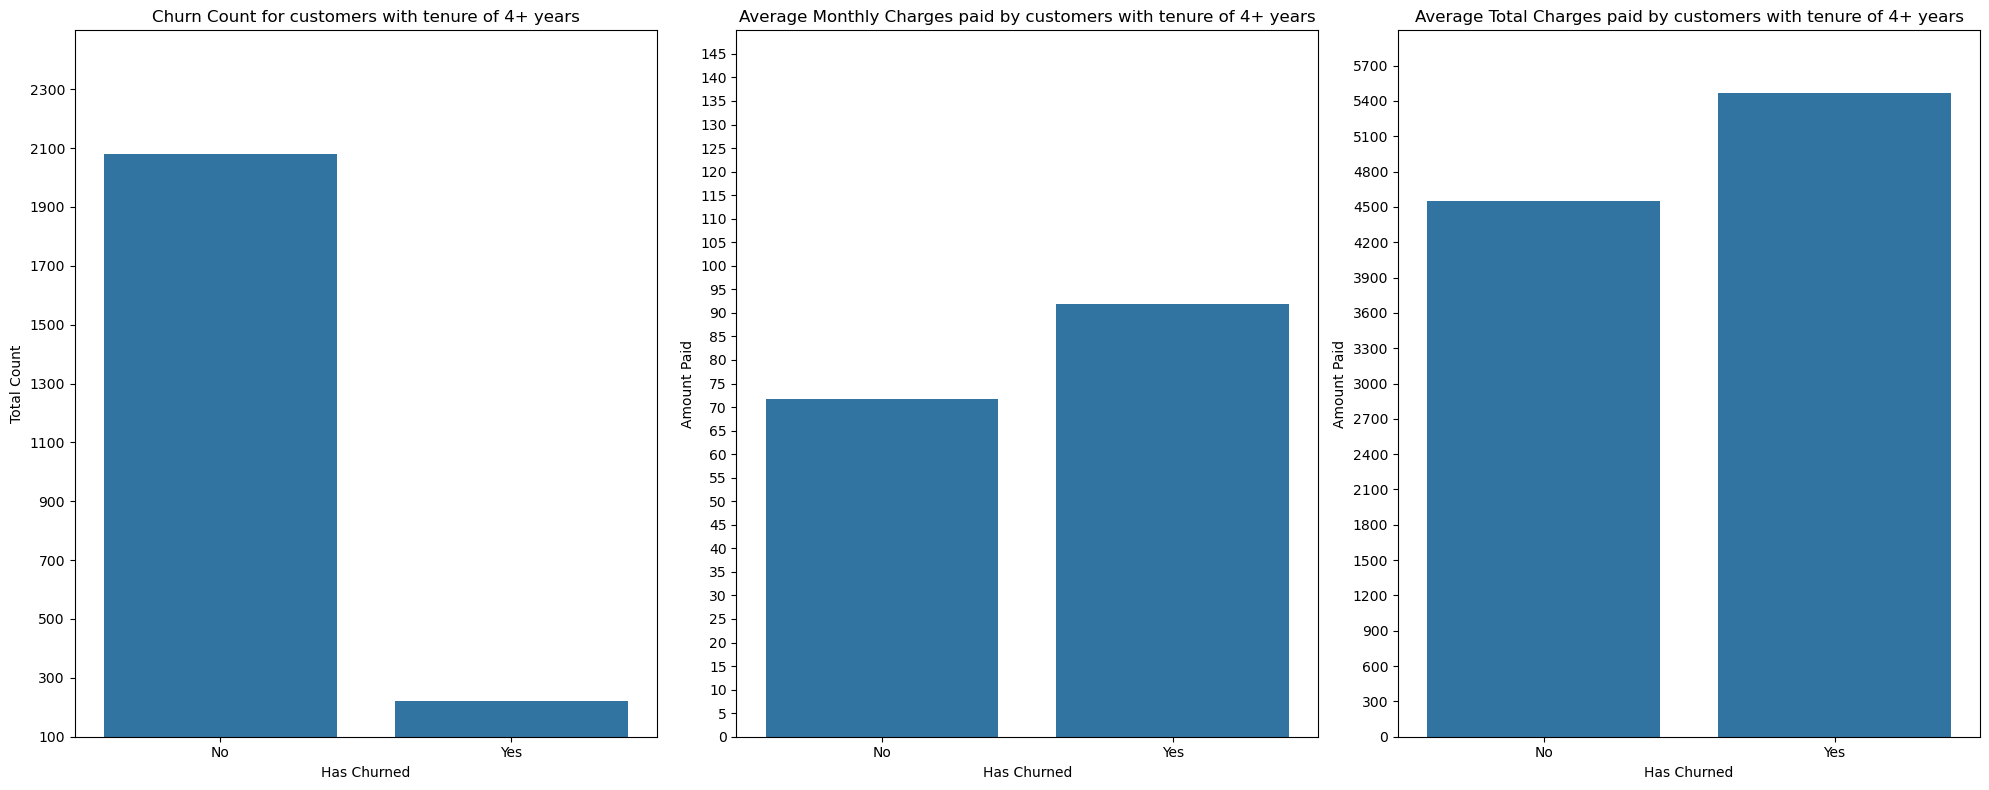

In [ ]:
### Stack Bar Graph of the amount paid by the customers with 4+ years of tenure 
fig, ax = plt.subplots(1,3,figsize = (20,8))
def plotting_charges(x, y , data, title, xlabel, ylabel, ylim1,ylim2, axes,num):
    sns.barplot(x = x, y = y , data = data, ax = axes)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.set_yticks(np.arange(ylim1,ylim2, num))
    axes.set_ylim(ylim1, ylim2)
    axes.yaxis.set_visible(True)
    plt.tight_layout()

plotting_charges('Churn','totalchurn', moneyfouryears, 'Churn Count for customers with tenure of 4+ years', 'Has Churned', 'Total Count', 100,2500, ax[0],200)
plotting_charges('Churn','averagemonthly', moneyfouryears, 'Average Monthly Charges paid by customers with tenure of 4+ years', 'Has Churned', 'Amount Paid', 0,150, ax[1], 5)
plotting_charges('Churn','totalcharges', moneyfouryears, 'Average Total Charges paid by customers with tenure of 4+ years', 'Has Churned', 'Amount Paid', 0,6000, ax[2], 300)

### As seen in the graph the customer who churned after 4+ years paid both, monthly and total, charges more compared to the individuals who did not churn 

---

### Types of contract and types of internet service used

In [ ]:
query = """ 
with contractypes as (select "Churn", "Contract",
COUNT(*) as contractused
from cleaned 
where "tenure" >= 48
group by "Contract", "Churn"),

internetservice as ( 
	select "Churn", "InternetService", COUNT(*) as serviceused
	from cleaned
	where "tenure" >= 48
	group by "InternetService", "Churn")	

select c."Churn", c."Contract", c."contractused", i."InternetService", i."serviceused"
from contractypes as c
join internetservice as i
on c."Churn" = i."Churn"
"""

contractcount = pd.read_sql(query, connection)
contractcount.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/630737672.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  contractcount = pd.read_sql(query, connection)


,Churn,Contract,contractused,InternetService,serviceused
0,No,Month-to-month,265,DSL,776
1,No,One year,575,DSL,776
2,No,Two year,1241,DSL,776
3,Yes,One year,87,No,6
4,Yes,Month-to-month,92,No,6


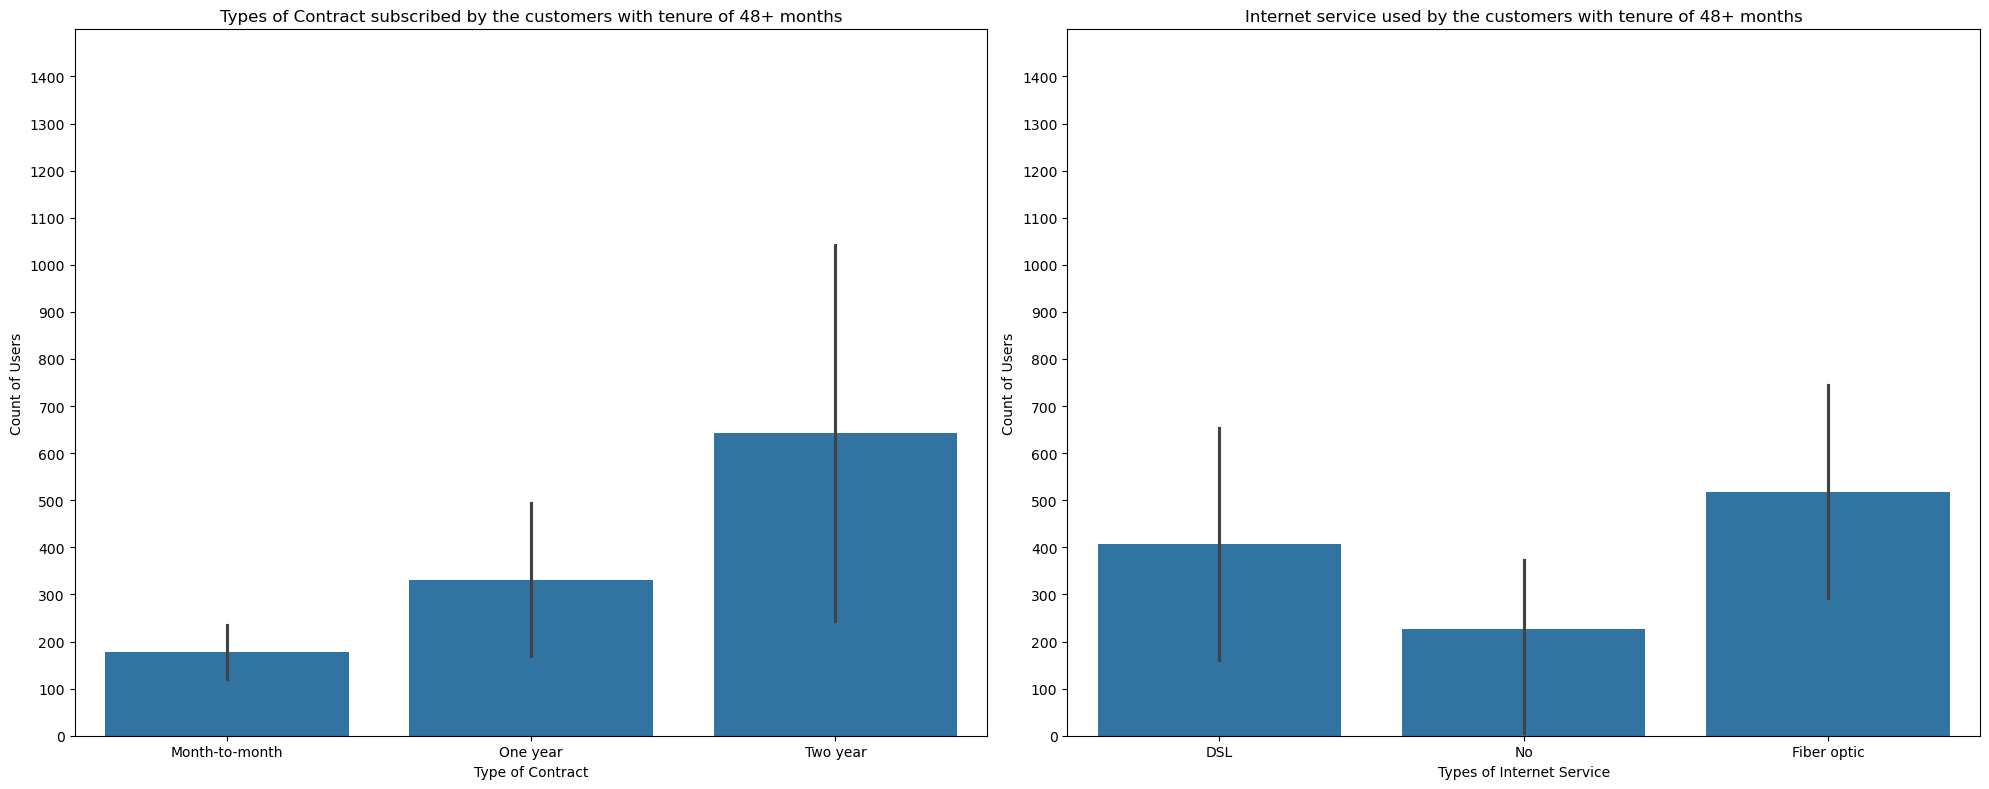

In [ ]:
## Plotting the graph 
fig, ax = plt.subplots(1,2,figsize = (20,8))
def contract_plotting(x, y , data, title, xlabel, ylabel, ylim1,ylim2, axes,num):
    sns.barplot(x = x, y = y , data = data, ax = axes)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.set_yticks(np.arange(ylim1,ylim2, num))
    axes.set_ylim(ylim1, ylim2)
    axes.yaxis.set_visible(True)
    plt.tight_layout()
contract_plotting('Contract', 'contractused', contractcount,'Types of Contract subscribed by the customers with tenure of 48+ months', 'Type of Contract', 'Count of Users', 0,1500,ax[0],100)
contract_plotting('InternetService', 'serviceused', contractcount,'Internet service used by the customers with tenure of 48+ months', 'Types of Internet Service', 'Count of Users', 0,1500,ax[1],100)

---
### Demographics Churn Rate 



In [ ]:
query = """ 
select 'SeniorCitizen' as category, case when "SeniorCitizen" = 1 then 'Yes' else 'No' end as haschurned,  ROUND(100 * SUM(case when "Churn"= 'Yes' then 1 else 0 end )::numeric / COUNT(*),2)
from cleaned
group by "SeniorCitizen"

union all

select 'Partner' as category, "Partner" as haschurned, ROUND(100 * SUM(case when "Churn"= 'Yes' then 1 else 0 end )::numeric / COUNT(*),2)
from cleaned 
group by "Partner"

union all

select 'Dependents' as category,"Dependents" as haschurned, ROUND(100 * SUM(case when "Churn"= 'Yes' then 1 else 0 end )::numeric / COUNT(*),2)
from cleaned 
group by "Dependents"
"""

demographicstats = pd.read_sql(query, connection)
demographicstats.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/3116228939.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  demographicstats = pd.read_sql(query, connection)


,category,haschurned,round
0,SeniorCitizen,No,23.61
1,SeniorCitizen,Yes,41.68
2,Partner,No,32.96
3,Partner,Yes,19.66
4,Dependents,No,31.28


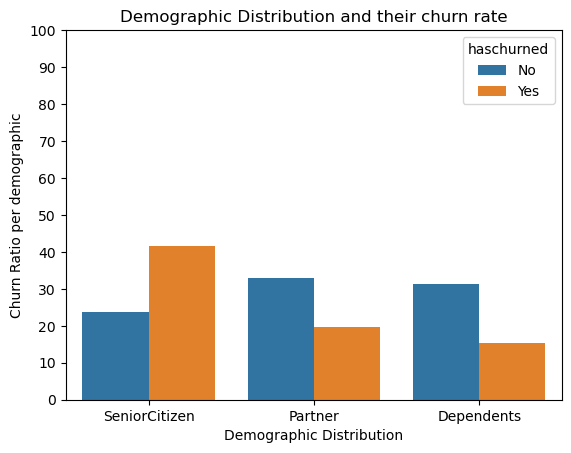

In [ ]:
sns.barplot(x = 'category', y  = 'round', hue = 'haschurned', data = demographicstats)
plt.ylim(0,100)
plt.ylabel("Churn Ratio per demographic")
plt.xlabel("Demographic Distribution")
plt.title("Demographic Distribution and their churn rate")
plt.yticks(np.arange(0,110,10))
plt.show()

### As seen Senior Citizens are more likely to churn compared to the Spouses and Dependents.

---

### Churn rate of combination of Contract and Payment Method 

In [ ]:
query = """ 
select "Contract", "PaymentMethod", ROUND(100 * SUM(case when "Churn"= 'Yes' then 1 else 0 end )::numeric / COUNT(*),2) as churnrate 
from cleaned 
group by "Contract", "PaymentMethod"
order by churnrate
"""

contractpayment = pd.read_sql(query, connection)
contractpayment.head(5)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/1751889226.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  contractpayment = pd.read_sql(query, connection)


,Contract,PaymentMethod,churnrate
0,Two year,Mailed check,0.79
1,Two year,Credit card (automatic),2.24
2,Two year,Bank transfer (automatic),3.37
3,One year,Mailed check,6.82
4,Two year,Electronic check,7.74


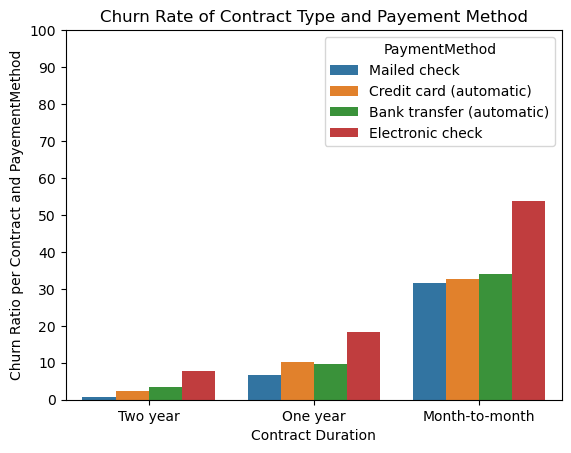

In [ ]:
### Plotting the graph 

sns.barplot(x = 'Contract', y  = 'churnrate', hue = 'PaymentMethod', data = contractpayment)
plt.ylim(0,100)
plt.ylabel("Churn Ratio per Contract and PayementMethod")
plt.xlabel("Contract Duration")
plt.title("Churn Rate of Contract Type and Payement Method")
plt.yticks(np.arange(0,110,10))
plt.show()

### Two year contract holders hold the less churn rate compared to other two contract types, The payment method "Mailed Check" with two year contract tend to have the lowest churn rate. Similary, all the payment methods used in two-year churn rate have the lowest churn rate comparatively.

---

### Paperless Billing Impact 

In [ ]:
query = """ 
select "PaperlessBilling", ROUND(100 * SUM(case when "Churn"= 'Yes' then 1 else 0 end )::numeric/COUNT(*),2) as total_churn
from cleaned
group by "PaperlessBilling"
"""

paperlessdata = pd.read_sql(query,connection)
paperlessdata.head(4)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/3455952144.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  paperlessdata = pd.read_sql(query,connection)


,PaperlessBilling,total_churn
0,No,16.33
1,Yes,33.57


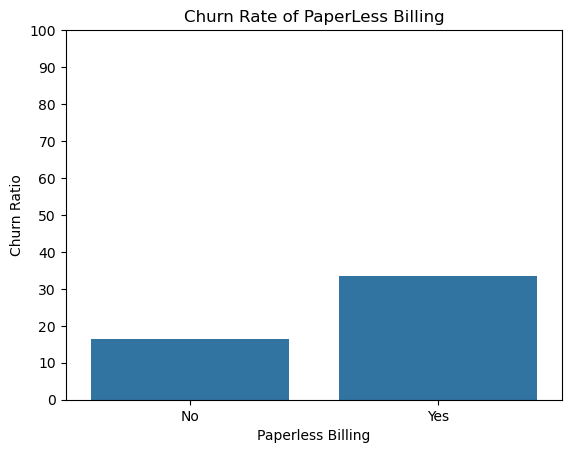

In [ ]:
sns.barplot(x = 'PaperlessBilling', y  = 'total_churn', data = paperlessdata)
plt.ylim(0,100)
plt.ylabel("Churn Ratio")
plt.xlabel("Paperless Billing")
plt.title("Churn Rate of PaperLess Billing")
plt.yticks(np.arange(0,110,10))
plt.show()

### As seen from the graph the 40% of the people who churned used paperless billing compared to the one with the paper billing

---

### Revenue at Risk

### From the recent analysis we have figured out that the highest churn rate is in those who use Fibre Optic cable, used Electronic Check as the way of paying bills, and month-to-month contract. So lets evaluate the potential loss that the compnay could bear since these are the parameters with the highest churn risk. 

---

### Revenue the business could loose / Revenue at Risk 


In [ ]:
query = """ 
select SUM("TotalCharges") as total, COUNT(*) as customeratrisk
from cleaned 
where "Churn" = 'No' and "PaymentMethod" = 'Electronic check' and "Contract" = 'Month-to-month' and "InternetService" = 'Fiber optic'
"""

onriskcustomers = pd.read_sql(query,connection)
onriskcustomers.head(2)

/var/folders/bt/9_3kc80d4jq8sv8fv_c7d_fr0000gn/T/ipykernel_92233/4083790107.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  onriskcustomers = pd.read_sql(query,connection)


,total,customeratrisk
0,1219148.4,518



### As seen from the stats, 518 customers are on risk whereas the company could loose nearly $1,219,148 as the part of total loss
---

---

### Conclusion Statement

### After doing the detailed analysis of our data, and different parameters that effect the churn rate, here are few key notable things. 

### 1. Gender Participation and Churn Rate: Even though Men have slightly more data in this dataset compared to Women, the churn rate is slightly higher for women (26.92%) compared to men(26.16%)

### TODO TOMORROW 
### Merge the gender distribution, and gender churn rate in the same graph using axes,and subplots, 
### Do same for the Senior Citizen participation 

#